Clean up

In [22]:
import pandas as pd

na_cleaned_df = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/NA/EKP/CV/na_cleaned.csv"
)
na_df = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/NA/EKP/parsed/exisiting_EKP_nan_parsed.csv"
)
filtered_na_df = na_df[na_df["Sample_ID_IfH"].isin(na_cleaned_df["Sample_ID_IfH"])]
filtered_na_df.to_csv("EKP_nan_parsed_cleaned.csv", index=False)

print(len(filtered_na_df))


vitek_cleaned_df = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/NA/EKP/CV/VITEK_cleaned.csv"
)
vitek_df = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/VITEK_combined_02_26_parsed.csv"
)
filtered_vitek_df = vitek_df[
    vitek_df["Sample_ID_IfH"].isin(vitek_cleaned_df["Sample_ID_IfH"])
]
filtered_vitek_df.to_csv("EKP_vitek_parsed_cleaned.csv", index=False)

print(len(filtered_vitek_df))

phoenix_cleaned_df = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/NA/EKP/CV/phoenix_cleaned.csv"
)
phoenix_df = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/phoenix_combined_02_26_parsed.csv"
)
filtered_phoenix_df = phoenix_df[
    phoenix_df["Sample_ID_IfH"].isin(phoenix_cleaned_df["Sample_ID_IfH"])
]
filtered_phoenix_df.to_csv("EKP_phoenix_parsed_cleaned.csv", index=False)

print(len(filtered_phoenix_df))

/local/tmp/ipykernel_475789/2334544091.py:6: DtypeWarning: Columns (0: imipenem/relebactam, 1: ceftaroline, 2: doxycycline, 3: cephalothin, 4: cefiderocol, 5: florfenicol, 6: sulfamethoxazole) have mixed types. Specify dtype option on import or set low_memory=False.
  na_df = pd.read_csv(


1862
848
1575


Train classifier with Phoenix and VITEK EKP Data

In [23]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ==================================================
# LOAD DEVICE DATASETS
# ==================================================


df_vitek = pd.read_csv("EKP_vitek_parsed_cleaned.csv")
df_phoenix = pd.read_csv("EKP_phoenix_parsed_cleaned.csv")


df_vitek = df_vitek[df_vitek["Organism_Code"].str.contains("EKP", case=False, na=False)]

df_phoenix = df_phoenix[
    df_phoenix["Organism_Code"].str.contains("EKP", case=False, na=False)
]


# ==================================================
# DEVICE LABELS
# ==================================================

df_vitek["device"] = "VITEK"
df_phoenix["device"] = "PHOENIX"

# ==================================================
# COMBINE DATASETS
# ==================================================

df = pd.concat([df_vitek, df_phoenix], ignore_index=True)

print("Combined shape:", df.shape)

# ==================================================
# TARGET
# ==================================================

y = df["device"]

# ==================================================
# FEATURES
# ==================================================

exclude_cols = ["Sample_ID_IfH", "device", "Organism_Code"]

X = df.drop(columns=exclude_cols)

# ==================================================
# HANDLE MISSING VALUES
# ==================================================

X = X.fillna("MISSING")
X = X.astype(str)

# ==================================================
# CATEGORICAL ENCODING
# ==================================================

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_encoded = encoder.fit_transform(X)
X_encoded = pd.DataFrame(encoder.fit_transform(X), columns=X.columns, index=X.index)

# ==================================================
# TRAIN / TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# ==================================================
# TRAIN CLASSIFIER
# ==================================================

clf = RadiusNeighborsClassifier(
    radius=0.1,
    metric="hamming",
    weights="distance",
    outlier_label="UNKNOWN",
)

clf.fit(X_train, y_train)

# ==================================================
# EVALUATION
# ==================================================

y_pred = clf.predict(X_test)

# ==================================================
# CLASSIFICATION REPORT
# ==================================================

report_dict = classification_report(y_test, y_pred, output_dict=True)

report_df = pd.DataFrame(report_dict).transpose()

report_df.to_csv("classification_report.csv", index=True)

print("\nSaved:")
print("classification_report.csv")

# ==================================================
# CONFUSION MATRIX
# ==================================================

labels = sorted(list(set(y_test) | set(y_pred)))
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.to_csv("confusion_matrix.csv", index=True)

Combined shape: (2423, 52)

Saved:
classification_report.csv


/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:868: UserWarning: Outlier label UNKNOWN is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/projects/envs/conda/jzander/envs/

Get device specific features

In [24]:
# ==================================================
# FEATURE-WISE DEVICE SPECIFICITY CSV
# ==================================================

results = []

for col in X.columns:

    counts = pd.crosstab(df["device"], X[col])
    rel_counts = pd.crosstab(df["device"], X[col], normalize="index")

    for category in counts.columns:
        row = {"feature": col, "category": category}
        freqs = []
        for device in counts.index:

            count = counts.loc[device, category]
            freq = rel_counts.loc[device, category]
            row[f"{device}_count"] = count
            row[f"{device}_freq"] = round(freq, 5)

            freqs.append(freq)

        # ------------------------------------------
        # DEVICE SPECIFICITY
        # ------------------------------------------
        row["specificity"] = round(max(freqs) - min(freqs), 5)
        results.append(row)

# ==================================================
# SAVE
# ==================================================

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("specificity", ascending=False)
results_df.to_csv("feature_wise_device_specificity.csv", index=False)
print(results_df.head(20))

                           feature category  PHOENIX_count  PHOENIX_freq  \
143                     ampicillin      >16           1551       0.98476   
56                       ertapenem  MISSING           1575       1.00000   
402                      cefazolin      >16           1411       0.89587   
350                     cefuroxime      >16           1404       0.89143   
381           ampicillin/sulbactam    >16/8           1386       0.88000   
145                     ampicillin     >=32              0       0.00000   
190                    ceftriaxone      >32           1361       0.86413   
263                  ciprofloxacin       >2           1352       0.85841   
117                     cefotaxime  MISSING           1575       1.00000   
294                    ceftazidime      >16           1315       0.83492   
82                     tigecycline  MISSING           1575       1.00000   
313                      aztreonam      >16           1245       0.79048   
423         

Predict MicroScan and Sensititre to validate UNKNOWN classification

In [25]:
def predict(df_unknown):
    df_unknown = df_unknown.dropna(subset=df_unknown.columns[2:], how="all")
    df_unknown = df_unknown[
        df_unknown["Organism_Code"].str.contains("EKP", case=False, na=False)
    ]

    # Encode unknown samples
    X_unknown = df_unknown.drop(columns=["Sample_ID_IfH"])
    missing_cols = set(X.columns) - set(X_unknown.columns)
    for col in missing_cols:
        X_unknown[col] = "MISSING"
    extra_cols = set(X_unknown.columns) - set(X.columns)
    if len(extra_cols) > 0:
        X_unknown = X_unknown.drop(columns=list(extra_cols))
    X_unknown = X_unknown[X.columns]
    X_unknown = X_unknown.fillna("MISSING")
    X_unknown = X_unknown.astype(str)
    print(len(X_unknown))
    X_unknown_encoded = encoder.transform(X_unknown)

    # Prediction
    predictions = clf.predict(X_unknown_encoded)
    distances, indices = clf.radius_neighbors(X_unknown_encoded, return_distance=True)

    # Results
    sample_ids = df_unknown["Sample_ID_IfH"]
    results = pd.DataFrame(
        {
            "Sample_ID": sample_ids,
            "Predicted_Device": predictions,
            "Neighbor_Count": [len(i) for i in indices],
            "Mean_Distance": [np.mean(d) if len(d) > 0 else np.nan for d in distances],
        }
    )

    print("\nPredicted Device Distribution")
    print(results["Predicted_Device"].value_counts(normalize=True))


df_microscan = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/MicroScan_combined_02_26_parsed.csv"
)
df_sensititre = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/Sensititre_combined_02_26_parsed.csv"
)

print("Mircoscan Results:")
predict(df_microscan)
print("Sensititre Results:")
predict(df_sensititre)

Mircoscan Results:
23

Predicted Device Distribution
Predicted_Device
UNKNOWN    1.0
Name: proportion, dtype: float64
Sensititre Results:
22

Predicted Device Distribution
Predicted_Device
UNKNOWN    1.0
Name: proportion, dtype: float64


/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RadiusNeighborsClassifier was fitted with feature names
  warnings.warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:868: UserWarning: Outlier label UNKNOWN is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RadiusNeighborsClassifier was fitted with feature names
  warnings.warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RadiusNeighborsClassifier was fitted with feature names
  warnings.warn(
/projects/envs/con

Predict NA samples

In [26]:
df_microscan = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/MicroScan_combined_02_26_parsed.csv"
)
df_sensititre = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/Sensititre_combined_02_26_parsed.csv"
)
df_na = pd.read_csv("EKP_nan_parsed_cleaned.csv")

print("NA Results:")
predict(df_na)

NA Results:
1862


/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RadiusNeighborsClassifier was fitted with feature names
  warnings.warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/neighbors/_classification.py:868: UserWarning: Outlier label UNKNOWN is not in training classes. All class probabilities of outliers will be assigned with 0.
  warnings.warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RadiusNeighborsClassifier was fitted with feature names
  warnings.warn(



Predicted Device Distribution
Predicted_Device
UNKNOWN    0.995166
VITEK      0.004834
Name: proportion, dtype: float64


Plot VITEK, Phoenix with microscan and sensititre -> Big microscan/VITEK overlap explains prediction results

Combined shape: (2468, 83)


/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


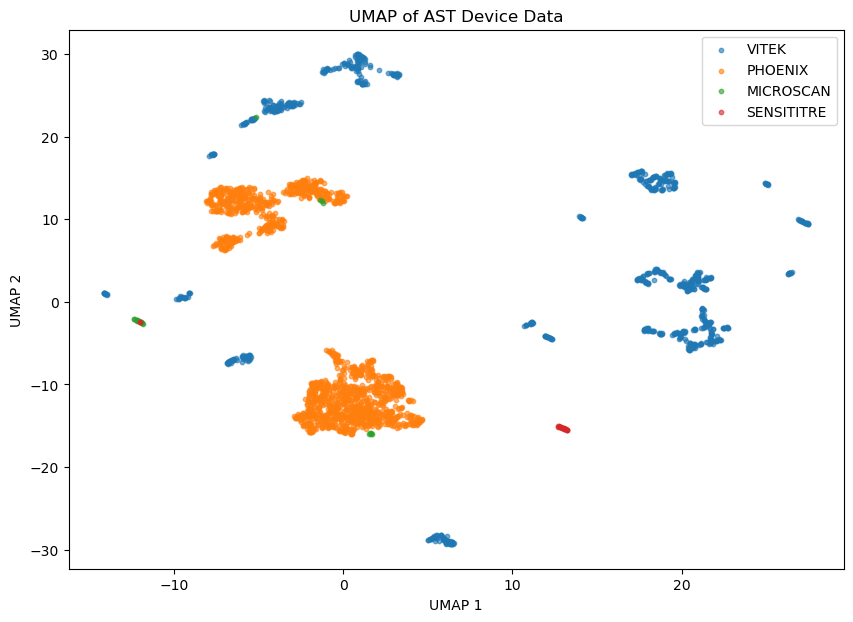

In [27]:
import umap
import matplotlib.pyplot as plt

df_vitek = pd.read_csv("EKP_vitek_parsed_cleaned.csv")
df_phoenix = pd.read_csv("EKP_phoenix_parsed_cleaned.csv")
df_microscan = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/MicroScan_combined_02_26_parsed.csv"
)
df_sensititre = pd.read_csv(
    "/groups/ds/Win-KID/BVBRC/BVBRC_devices/parsed/Sensititre_combined_02_26_parsed.csv"
)


df_vitek = df_vitek[df_vitek["Organism_Code"].str.contains("EKP", case=False, na=False)]

df_phoenix = df_phoenix[
    df_phoenix["Organism_Code"].str.contains("EKP", case=False, na=False)
]

df_microscan = df_microscan[
    df_microscan["Organism_Code"].str.contains("EKP", case=False, na=False)
]

df_sensititre = df_sensititre[
    df_sensititre["Organism_Code"].str.contains("EKP", case=False, na=False)
]

# ==================================================
# DEVICE LABELS
# ==================================================

df_vitek["device"] = "VITEK"
df_phoenix["device"] = "PHOENIX"
df_microscan["device"] = "MICROSCAN"
df_sensititre["device"] = "SENSITITRE"

# ==================================================
# COMBINE DATASETS
# ==================================================

df = pd.concat(
    [
        df_vitek,
        df_phoenix,
        df_microscan,
        df_sensititre,
    ],
    ignore_index=True,
)

print("Combined shape:", df.shape)

# ==================================================
# TARGET
# ==================================================

y = df["device"]

# ==================================================
# FEATURES
# ==================================================

exclude_cols = ["Sample_ID_IfH", "device", "Organism_Code"]

X = df.drop(columns=exclude_cols)

# ==================================================
# HANDLE MISSING VALUES
# ==================================================

# Fehlende Werte explizit markieren
X = X.fillna("MISSING")

# Alles als String behandeln
X = X.astype(str)

# ==================================================
# CATEGORICAL ENCODING
# ==================================================

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_encoded = encoder.fit_transform(X)
X_encoded = pd.DataFrame(encoder.fit_transform(X), columns=X.columns, index=X.index)

# ==================================================
# UMAP MODEL
# ==================================================

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.5,
    # n_neighbors=10,
    # min_dist=0.2,
    # n_neighbors=70,
    # min_dist=0.3,
    # n_neighbors=15,
    # min_dist=0.5,
    metric="hamming",  # wichtig bei deinem Encoding
    random_state=42,
)

embedding = reducer.fit_transform(X_encoded)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(10, 7))

for device in y.unique():
    idx = y == device
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=device, alpha=0.6, s=10)

plt.title("UMAP of AST Device Data")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.savefig("umap_ast_devices.svg", format="svg", bbox_inches="tight")
plt.show()

Check Cluster Size of UMAP

In [28]:
embedding = reducer.fit_transform(X_encoded)

df_umap = pd.DataFrame(
    {"UMAP1": embedding[:, 0], "UMAP2": embedding[:, 1], "device": y.values}
)

x0 = df_umap["UMAP1"].median()
y0 = df_umap["UMAP2"].median()


def get_quadrant(row):
    if row.UMAP1 >= x0 and row.UMAP2 >= y0:
        return "Q1"
    elif row.UMAP1 < x0 and row.UMAP2 >= y0:
        return "Q2"
    elif row.UMAP1 < x0 and row.UMAP2 < y0:
        return "Q3"
    else:
        return "Q4"


df_umap["quadrant"] = df_umap.apply(get_quadrant, axis=1)

counts = pd.crosstab(df_umap["device"], df_umap["quadrant"])

print(counts)

#           y
#           ↑
#    Q2     |     Q1
#           |
# ----------+----------→ x
#           |
#    Q3     |     Q4
#           ↓

/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(


quadrant     Q1   Q2   Q3   Q4
device                        
MICROSCAN     4    0    5   14
PHOENIX     160  435  663  317
SENSITITRE    0    0    0   22
VITEK       576   59   72  141


Explained variance ratio: 0.260, 0.167


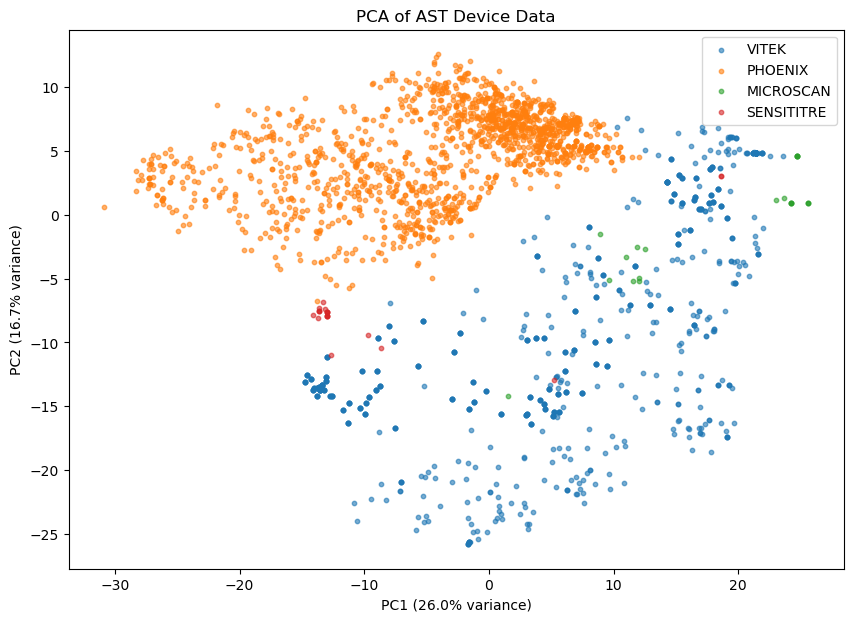

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==================================================
# PCA MODEL
# ==================================================

pca = PCA(n_components=2, random_state=42)

embedding = pca.fit_transform(X_encoded)

print(
    f"Explained variance ratio: "
    f"{pca.explained_variance_ratio_[0]:.3f}, "
    f"{pca.explained_variance_ratio_[1]:.3f}"
)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(10, 7))

for device in y.unique():
    idx = y == device
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=device, alpha=0.6, s=10)

plt.title("PCA of AST Device Data")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()

plt.savefig("pca_ast_devices.svg", format="svg", bbox_inches="tight")

plt.show()

Plot VITEK, Phoenix with NA -> VITEK and NA overlap explains prediction

Combined shape: (4285, 83)


/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/umap/umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
/projects/envs/conda/jzander/envs/python_notebook/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


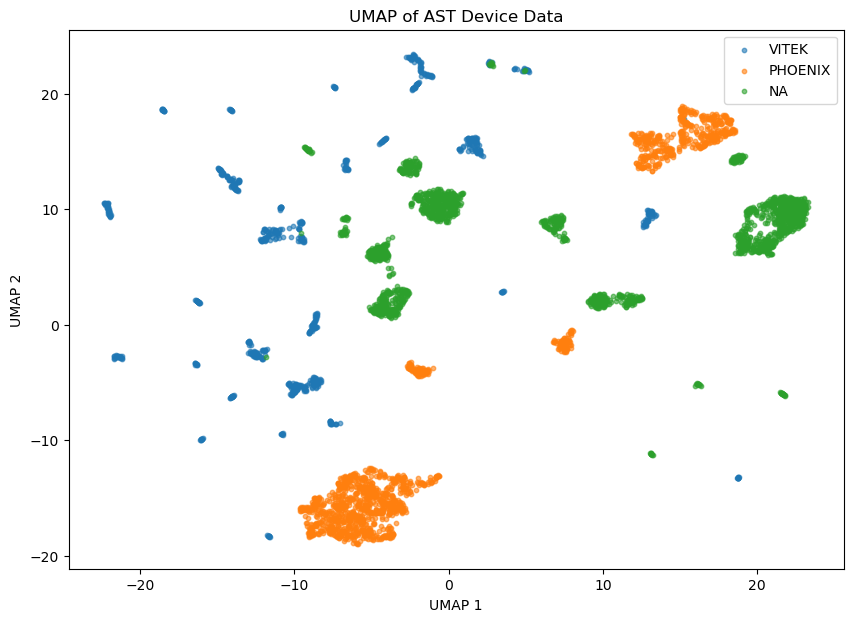

In [30]:
import umap
import matplotlib.pyplot as plt

df_vitek = pd.read_csv("EKP_vitek_parsed_cleaned.csv")
df_phoenix = pd.read_csv("EKP_phoenix_parsed_cleaned.csv")
df_na = pd.read_csv("EKP_nan_parsed_cleaned.csv")


df_vitek = df_vitek[df_vitek["Organism_Code"].str.contains("EKP", case=False, na=False)]

df_phoenix = df_phoenix[
    df_phoenix["Organism_Code"].str.contains("EKP", case=False, na=False)
]


df_na = df_na[df_na["Organism_Code"].str.contains("EKP", case=False, na=False)]

df_na = df_na.dropna(subset=df_na.columns[2:], how="all")


df_microscan = df_microscan[
    df_microscan["Organism_Code"].str.contains("EKP", case=False, na=False)
]

df_sensititre = df_sensititre[
    df_sensititre["Organism_Code"].str.contains("EKP", case=False, na=False)
]


# ==================================================
# DEVICE LABELS
# ==================================================

df_vitek["device"] = "VITEK"
df_phoenix["device"] = "PHOENIX"
df_microscan["device"] = "MICROSCAN"
df_sensititre["device"] = "SENSITITRE"
df_na["device"] = "NA"

# ==================================================
# COMBINE DATASETS
# ==================================================

df = pd.concat(
    [
        df_vitek,
        df_phoenix,
        # df_microscan,
        # df_sensititre,
        df_na,
    ],
    ignore_index=True,
)

print("Combined shape:", df.shape)

# ==================================================
# TARGET
# ==================================================

y = df["device"]

# ==================================================
# FEATURES
# ==================================================

exclude_cols = ["Sample_ID_IfH", "device", "Organism_Code"]

X = df.drop(columns=exclude_cols)

# ==================================================
# HANDLE MISSING VALUES
# ==================================================

# Fehlende Werte explizit markieren
X = X.fillna("MISSING")

# Alles als String behandeln
X = X.astype(str)

# ==================================================
# CATEGORICAL ENCODING
# ==================================================

encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_encoded = pd.DataFrame(encoder.fit_transform(X), columns=X.columns, index=X.index)

# ==================================================
# UMAP MODEL
# ==================================================

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.5,
    metric="hamming",  # wichtig bei deinem Encoding
    random_state=42,
)

embedding = reducer.fit_transform(X_encoded)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(10, 7))

for device in y.unique():
    idx = y == device
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=device, alpha=0.6, s=10)

plt.title("UMAP of AST Device Data")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.savefig("umap_ast_NA.svg", format="svg", bbox_inches="tight")
plt.show()

Explained variance ratio: 0.215, 0.165


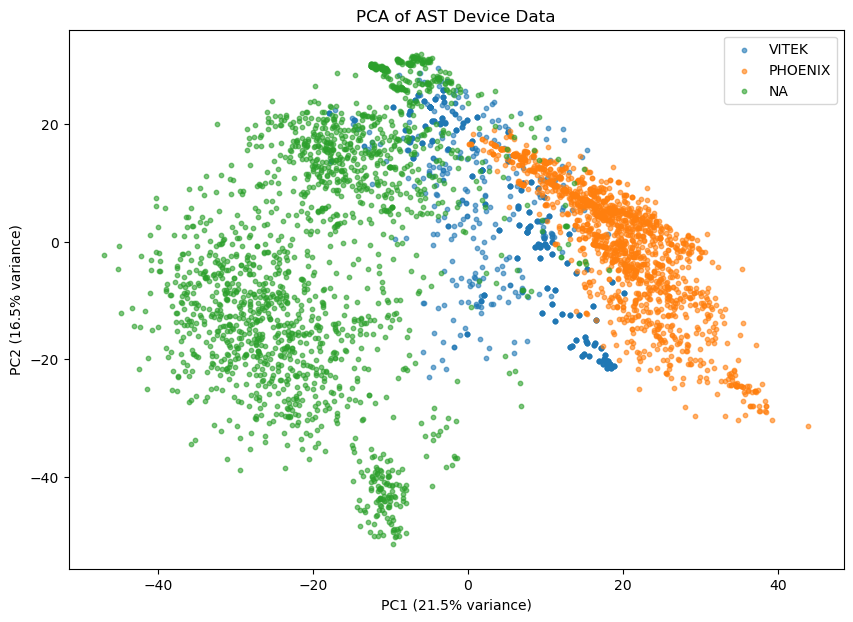

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==================================================
# PCA MODEL
# ==================================================

pca = PCA(n_components=2, random_state=42)

embedding = pca.fit_transform(X_encoded)

print(
    f"Explained variance ratio: "
    f"{pca.explained_variance_ratio_[0]:.3f}, "
    f"{pca.explained_variance_ratio_[1]:.3f}"
)

# ==================================================
# PLOT
# ==================================================

plt.figure(figsize=(10, 7))

for device in y.unique():
    idx = y == device
    plt.scatter(embedding[idx, 0], embedding[idx, 1], label=device, alpha=0.6, s=10)

plt.title("PCA of AST Device Data")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend()

plt.savefig("pca_ast_NA.svg", format="svg", bbox_inches="tight")

plt.show()